<a href="https://colab.research.google.com/github/JyoshanaviGudla-5/SCT_DS_4/blob/main/Task4_Traffic_Accident_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

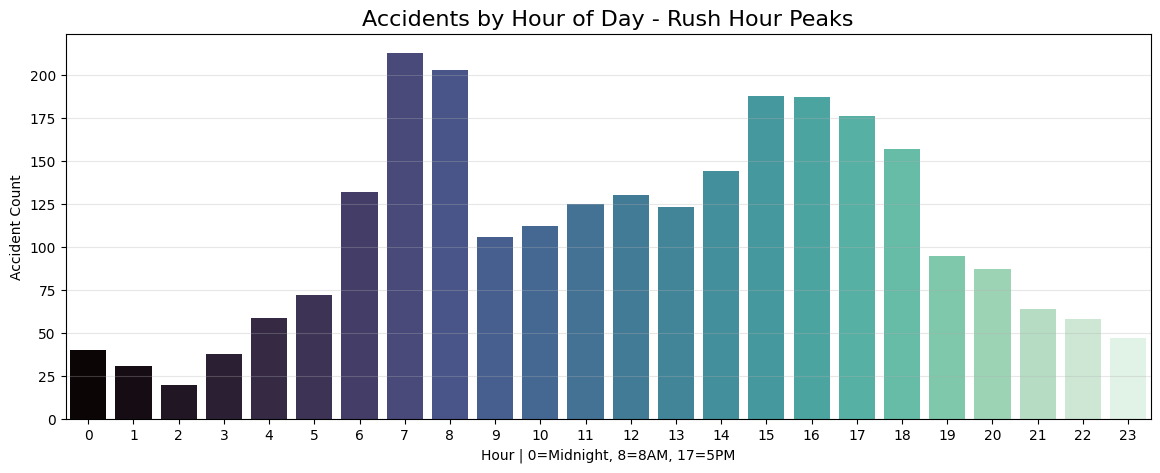

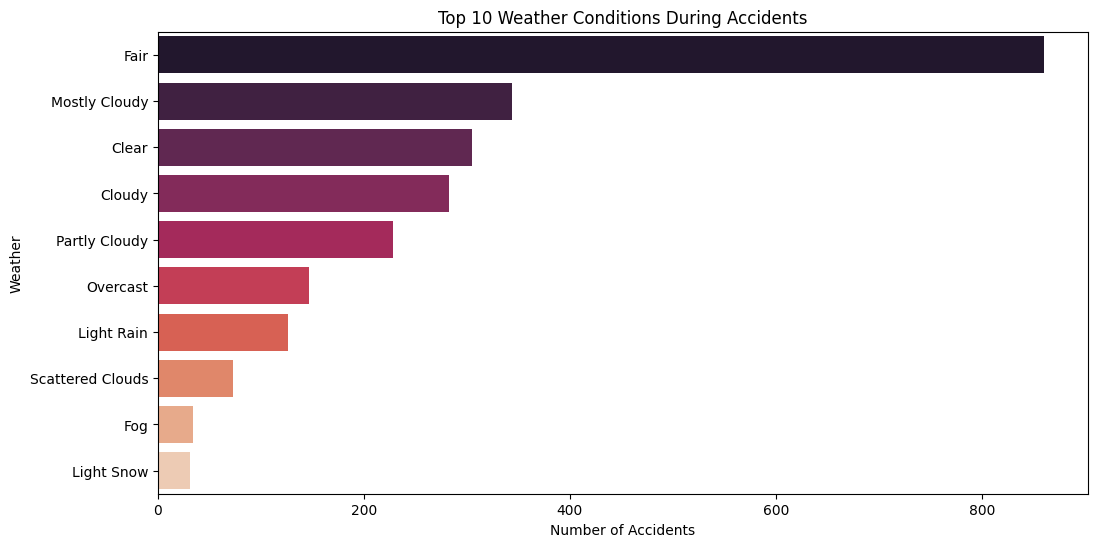

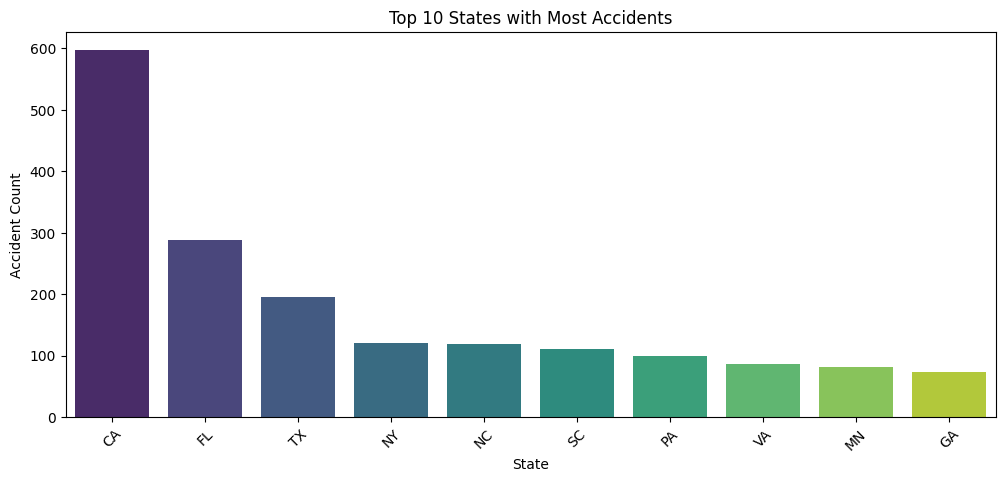

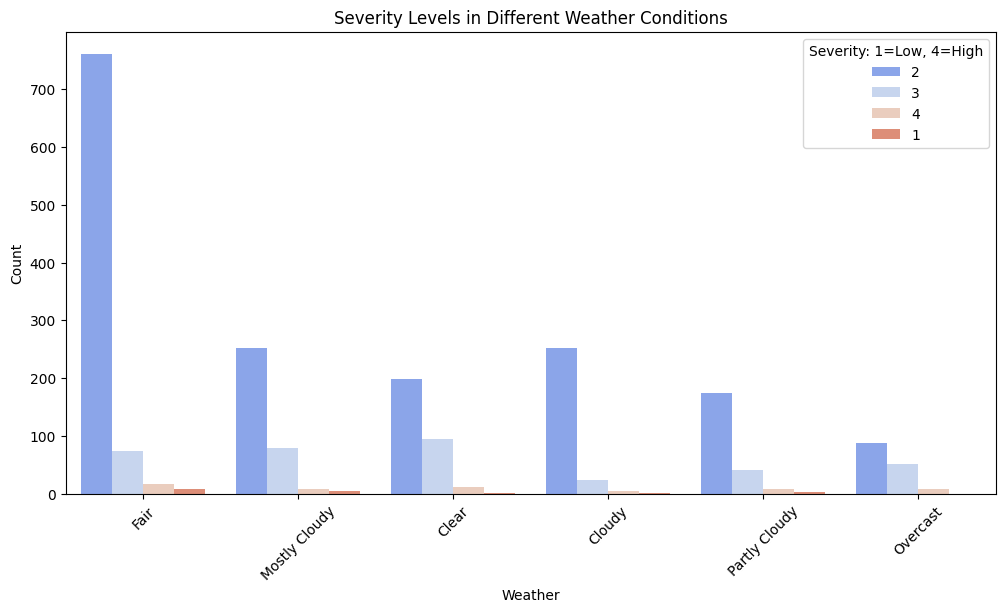

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

col_names = ['ID', 'Source', 'Severity', 'Start_Time', 'End_Time',
             'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)',
             'Description', 'Street', 'City', 'County', 'State', 'Zipcode',
             'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp',
             'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)',
             'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)',
             'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way',
             'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
             'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset',
             'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']

file_path = '/content/US_Accidents_March23_sampled_500k.csv'
df = pd.read_csv(file_path, header=None, names=col_names, nrows=50000)

df_clean = df[['Severity', 'Start_Time', 'Weather_Condition',
               'Start_Lat', 'Start_Lng', 'City', 'State']].copy()

df_clean['Start_Time'] = pd.to_datetime(df_clean['Start_Time'], errors='coerce')
df_clean.dropna(inplace=True)
df_clean = df_clean[df_clean['Weather_Condition'] != '']

df_clean['Hour'] = df_clean['Start_Time'].dt.hour
df_clean['Day'] = df_clean['Start_Time'].dt.day_name()

plt.figure(figsize=(14,5))
sns.countplot(x='Hour', data=df_clean, palette='mako', hue='Hour', legend=False)
plt.title('Accidents by Hour of Day - Rush Hour Peaks', fontsize=16)
plt.xlabel('Hour | 0=Midnight, 8=8AM, 17=5PM')
plt.ylabel('Accident Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

top_weather = df_clean['Weather_Condition'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_weather.values, y=top_weather.index, palette='rocket')
plt.title('Top 10 Weather Conditions During Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Weather')
plt.show()

top_states = df_clean['State'].value_counts().head(10)
plt.figure(figsize=(12,5))
sns.barplot(x=top_states.index, y=top_states.values, palette='viridis')
plt.title('Top 10 States with Most Accidents')
plt.xlabel('State')
plt.ylabel('Accident Count')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(x='Weather_Condition', hue='Severity', data=df_clean,
              order=df_clean['Weather_Condition'].value_counts().iloc[:6].index,
              palette='coolwarm')
plt.title('Severity Levels in Different Weather Conditions')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Severity: 1=Low, 4=High')
plt.show()

map_usa = folium.Map(location=[39.8283, -98.5795], zoom_start=4, tiles='CartoDB positron')
heat_data = [[row['Start_Lat'], row['Start_Lng']] for index, row in df_clean.head(5000).iterrows()]
HeatMap(heat_data, radius=15, blur=20, max_zoom=10).add_to(map_usa)
map_usa.save('accident_hotspots.html')
display(map_usa)

df_sample = df_clean.head(1000)
df_sample.to_csv('sample_for_github.csv', index=False)
